# HRF Library Sampling Analysis

This notebook explores how HRF library shapes change with different sampling resolutions:
1. Source resolution (0.1s) - as stored in the TSV file
2. Microtime resolution (TR/20 = 0.05s for TR=1.0)
3. TR resolution (1.0s)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Add parent to path if needed
sys.path.insert(0, str(Path.cwd().parent))

from fastfuncstuff.hrf import (
    _HRF_FILE_RESOLUTION,
    _HRF_LIBRARY_FILE,
    _load_hrf_from_file,
    get_hrf_library,
)

print(f"HRF file resolution: {_HRF_FILE_RESOLUTION}s")
print(f"HRF library file: {_HRF_LIBRARY_FILE}")

/home/logan/miniconda3/envs/py312_movie_tasks/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HRF file resolution: 0.1s
HRF library file: getcanonicalhrflibrary.tsv


## 1. Load Raw HRF Library (Source Resolution)

First, let's look at the HRFs exactly as they're stored in the file (0.1s resolution).

In [2]:
# Load raw library directly from file
raw_library = _load_hrf_from_file(_HRF_LIBRARY_FILE)
print(f"Raw library shape: {raw_library.shape}")
print(f"  {raw_library.shape[0]} timepoints x {raw_library.shape[1]} HRFs")
print(f"  Duration: {raw_library.shape[0] * _HRF_FILE_RESOLUTION}s at {_HRF_FILE_RESOLUTION}s resolution")

# Check peak values in raw file
print("\nRaw file peak values:")
for i in range(raw_library.shape[1]):
    peak_val = raw_library[:, i].max()
    peak_idx = raw_library[:, i].argmax()
    peak_time = peak_idx * _HRF_FILE_RESOLUTION
    print(f"  HRF {i+1:2d}: peak = {peak_val:.4f} at t = {peak_time:.1f}s")

Raw library shape: (501, 20)
  501 timepoints x 20 HRFs
  Duration: 50.1s at 0.1s resolution

Raw file peak values:
  HRF  1: peak = 0.0505 at t = 2.7s
  HRF  2: peak = 0.0468 at t = 2.8s
  HRF  3: peak = 0.0445 at t = 3.0s
  HRF  4: peak = 0.0442 at t = 3.0s
  HRF  5: peak = 0.0458 at t = 3.1s
  HRF  6: peak = 0.0460 at t = 3.3s
  HRF  7: peak = 0.0466 at t = 3.4s
  HRF  8: peak = 0.0460 at t = 3.6s
  HRF  9: peak = 0.0420 at t = 3.9s
  HRF 10: peak = 0.0374 at t = 4.1s
  HRF 11: peak = 0.0330 at t = 4.3s
  HRF 12: peak = 0.0292 at t = 4.5s
  HRF 13: peak = 0.0262 at t = 4.7s
  HRF 14: peak = 0.0233 at t = 4.9s
  HRF 15: peak = 0.0213 at t = 5.1s
  HRF 16: peak = 0.0200 at t = 5.3s
  HRF 17: peak = 0.0188 at t = 5.4s
  HRF 18: peak = 0.0178 at t = 5.6s
  HRF 19: peak = 0.0179 at t = 5.6s
  HRF 20: peak = 0.0175 at t = 5.7s


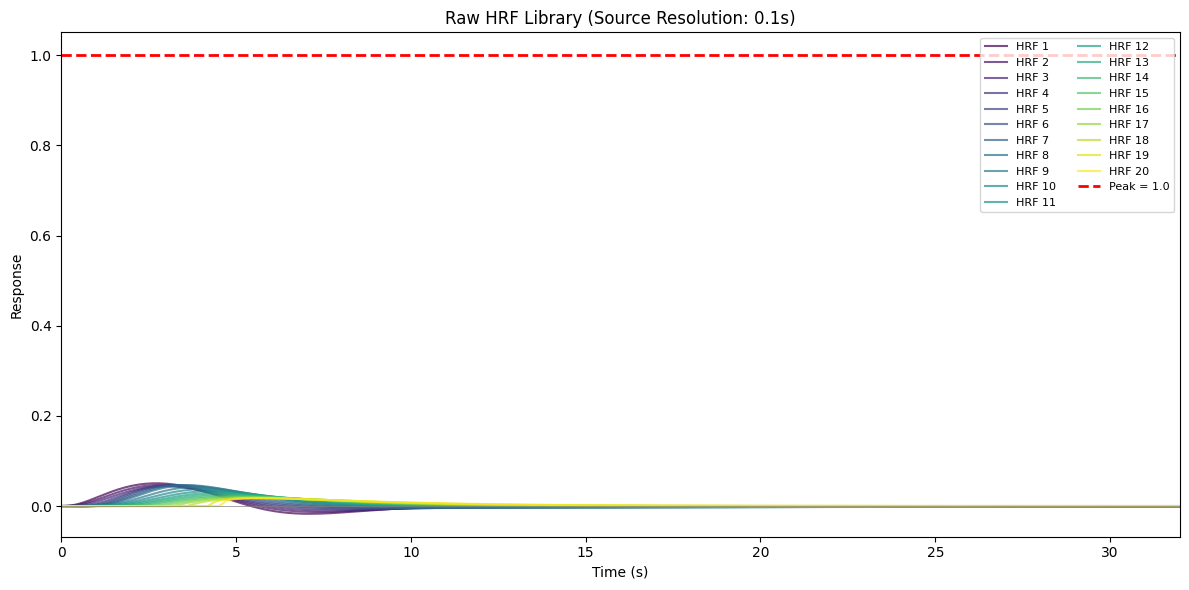


Note: Raw file HRFs are NOT normalized to peak=1.0
Max peak in raw file: 0.0505
Min peak in raw file: 0.0175


In [3]:
# Plot raw HRFs
fig, ax = plt.subplots(figsize=(12, 6))
time_source = np.arange(raw_library.shape[0]) * _HRF_FILE_RESOLUTION

cmap = plt.cm.viridis
n_hrfs = raw_library.shape[1]
for i in range(n_hrfs):
    color = cmap(i / (n_hrfs - 1))
    ax.plot(time_source, raw_library[:, i], color=color, alpha=0.7, label=f'HRF {i+1}')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Peak = 1.0')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
ax.set_title(f'Raw HRF Library (Source Resolution: {_HRF_FILE_RESOLUTION}s)')
ax.set_xlim(0, 32)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print("\nNote: Raw file HRFs are NOT normalized to peak=1.0")
print(f"Max peak in raw file: {raw_library.max():.4f}")
print(f"Min peak in raw file: {raw_library.max(axis=0).min():.4f}")

## 2. After Normalization (Still at Source Resolution)

The library loader normalizes each HRF to peak=1.0 at source resolution before resampling.

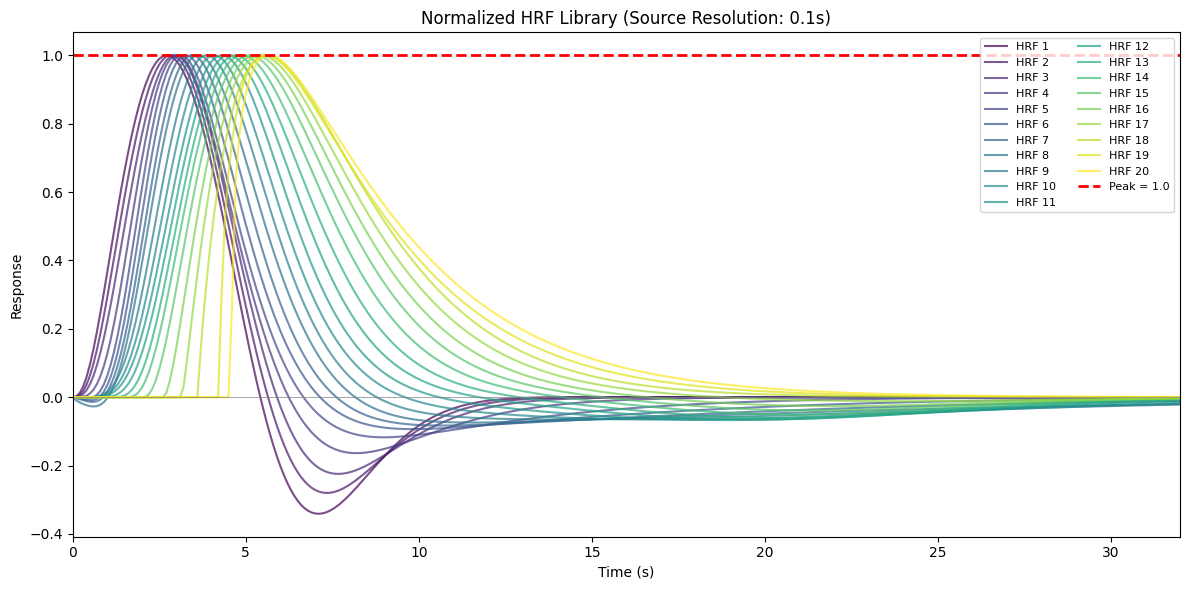

After normalization at source resolution:
  All peaks = 1.0000 to 1.0000


In [4]:
# Manually normalize to see the effect
raw_normalized = np.zeros_like(raw_library)
for i in range(raw_library.shape[1]):
    peak = raw_library[:, i].max()
    raw_normalized[:, i] = raw_library[:, i] / peak

# Plot normalized HRFs at source resolution
fig, ax = plt.subplots(figsize=(12, 6))

for i in range(n_hrfs):
    color = cmap(i / (n_hrfs - 1))
    ax.plot(time_source, raw_normalized[:, i], color=color, alpha=0.7, label=f'HRF {i+1}')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Peak = 1.0')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
ax.set_title(f'Normalized HRF Library (Source Resolution: {_HRF_FILE_RESOLUTION}s)')
ax.set_xlim(0, 32)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print("After normalization at source resolution:")
print(f"  All peaks = {raw_normalized.max(axis=0).min():.4f} to {raw_normalized.max(axis=0).max():.4f}")

## 3. At Microtime Resolution (TR/20 = 0.05s)

With TR=1.0 and microtime_resolution=20, we sample at 0.05s intervals.

In [5]:
tr = 1.0
microtime_res = 20
target_dt = tr / microtime_res

lib_microtime = get_hrf_library(mode='library', tr=tr, microtime_resolution=microtime_res)
lib_microtime_np = lib_microtime.cpu().numpy()

print(f"Microtime library shape: {lib_microtime.shape}")
print(f"  Target dt: {target_dt}s (TR={tr}s / microtime_resolution={microtime_res})")
print(f"  Duration: {lib_microtime.shape[1] * target_dt}s")

print("\nPeak values at microtime resolution:")
for i in range(lib_microtime.shape[0]):
    peak_val = lib_microtime_np[i].max()
    peak_idx = lib_microtime_np[i].argmax()
    peak_time = peak_idx * target_dt
    print(f"  HRF {i+1:2d}: peak = {peak_val:.4f} at t = {peak_time:.2f}s")

Microtime library shape: torch.Size([20, 640])
  Target dt: 0.05s (TR=1.0s / microtime_resolution=20)
  Duration: 32.0s

Peak values at microtime resolution:
  HRF  1: peak = 1.0000 at t = 2.70s
  HRF  2: peak = 1.0000 at t = 2.80s
  HRF  3: peak = 1.0000 at t = 3.00s
  HRF  4: peak = 1.0000 at t = 3.00s
  HRF  5: peak = 1.0000 at t = 3.10s
  HRF  6: peak = 1.0000 at t = 3.30s
  HRF  7: peak = 1.0000 at t = 3.40s
  HRF  8: peak = 1.0000 at t = 3.60s
  HRF  9: peak = 1.0000 at t = 3.90s
  HRF 10: peak = 1.0000 at t = 4.10s
  HRF 11: peak = 1.0000 at t = 4.30s
  HRF 12: peak = 1.0000 at t = 4.50s
  HRF 13: peak = 1.0000 at t = 4.70s
  HRF 14: peak = 1.0000 at t = 4.90s
  HRF 15: peak = 1.0000 at t = 5.10s
  HRF 16: peak = 1.0000 at t = 5.30s
  HRF 17: peak = 1.0000 at t = 5.40s
  HRF 18: peak = 1.0000 at t = 5.60s
  HRF 19: peak = 1.0000 at t = 5.60s
  HRF 20: peak = 1.0000 at t = 5.70s


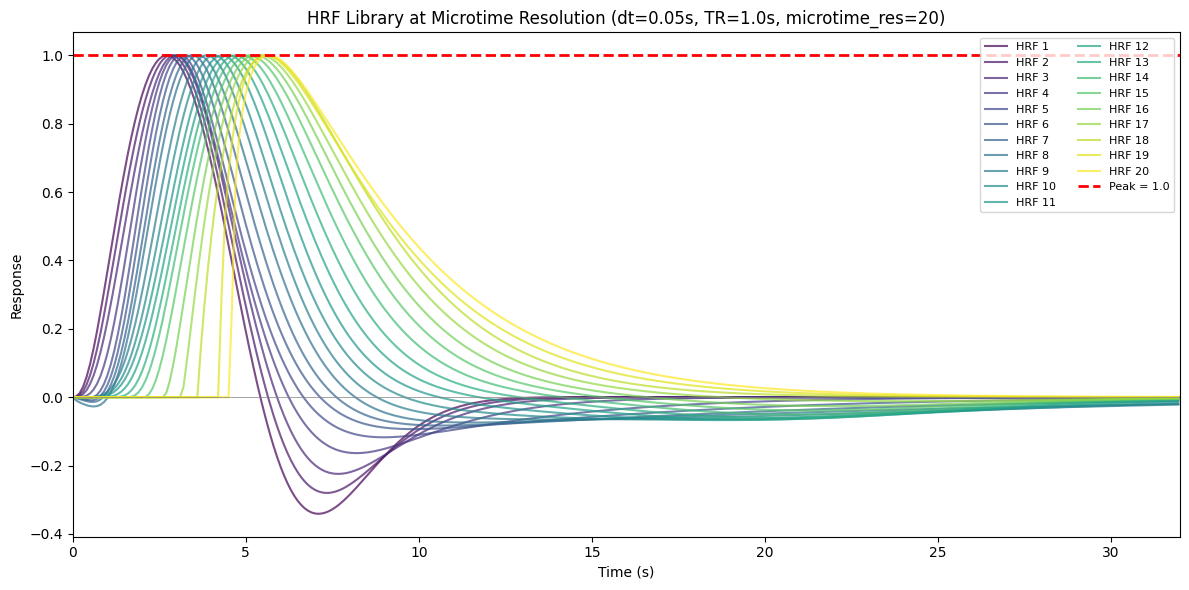


Microtime resolution peak summary:
  Min peak: 1.0000
  Max peak: 1.0000
  All >= 0.99: True


In [6]:
# Plot at microtime resolution
fig, ax = plt.subplots(figsize=(12, 6))
time_microtime = np.arange(lib_microtime.shape[1]) * target_dt

for i in range(lib_microtime.shape[0]):
    color = cmap(i / (lib_microtime.shape[0] - 1))
    ax.plot(time_microtime, lib_microtime_np[i], color=color, alpha=0.7, label=f'HRF {i+1}')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Peak = 1.0')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
ax.set_title(f'HRF Library at Microtime Resolution (dt={target_dt}s, TR={tr}s, microtime_res={microtime_res})')
ax.set_xlim(0, 32)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

peaks_microtime = lib_microtime_np.max(axis=1)
print("\nMicrotime resolution peak summary:")
print(f"  Min peak: {peaks_microtime.min():.4f}")
print(f"  Max peak: {peaks_microtime.max():.4f}")
print(f"  All >= 0.99: {np.all(peaks_microtime >= 0.99)}")

## 4. At TR Resolution (1.0s)

When sampling at TR resolution, peaks may be missed if they fall between samples.

In [7]:
lib_tr = get_hrf_library(mode='library', tr=tr, microtime_resolution=1)
lib_tr_np = lib_tr.cpu().numpy()

print(f"TR-resolution library shape: {lib_tr.shape}")
print(f"  Target dt: {tr}s")
print(f"  Duration: {lib_tr.shape[1] * tr}s")

print("\nPeak values at TR resolution:")
for i in range(lib_tr.shape[0]):
    peak_val = lib_tr_np[i].max()
    peak_idx = lib_tr_np[i].argmax()
    peak_time = peak_idx * tr
    print(f"  HRF {i+1:2d}: peak = {peak_val:.4f} at t = {peak_time:.1f}s")

TR-resolution library shape: torch.Size([20, 32])
  Target dt: 1.0s
  Duration: 32.0s

Peak values at TR resolution:
  HRF  1: peak = 0.9829 at t = 3.0s
  HRF  2: peak = 0.9943 at t = 3.0s
  HRF  3: peak = 1.0000 at t = 3.0s
  HRF  4: peak = 1.0000 at t = 3.0s
  HRF  5: peak = 0.9959 at t = 3.0s
  HRF  6: peak = 0.9790 at t = 3.0s
  HRF  7: peak = 0.9441 at t = 3.0s
  HRF  8: peak = 0.9696 at t = 4.0s
  HRF  9: peak = 0.9964 at t = 4.0s
  HRF 10: peak = 0.9985 at t = 4.0s
  HRF 11: peak = 0.9804 at t = 4.0s
  HRF 12: peak = 0.9611 at t = 5.0s
  HRF 13: peak = 0.9865 at t = 5.0s
  HRF 14: peak = 0.9985 at t = 5.0s
  HRF 15: peak = 0.9988 at t = 5.0s
  HRF 16: peak = 0.9899 at t = 5.0s
  HRF 17: peak = 0.9746 at t = 5.0s
  HRF 18: peak = 0.9838 at t = 6.0s
  HRF 19: peak = 0.9796 at t = 6.0s
  HRF 20: peak = 0.9865 at t = 6.0s


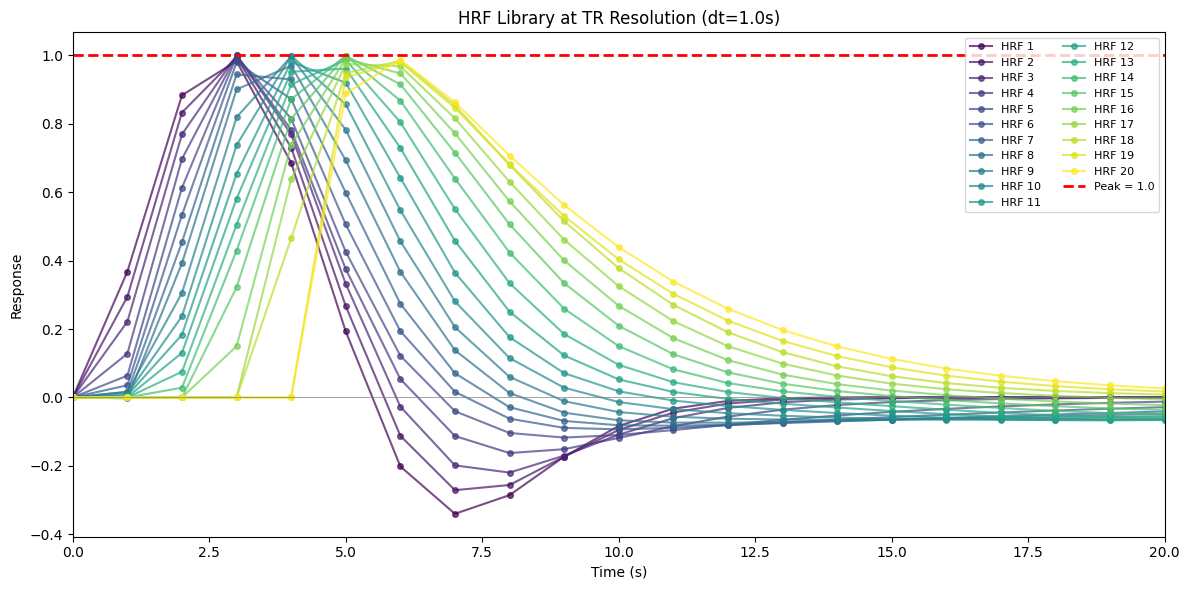


TR resolution peak summary:
  Min peak: 0.9441
  Max peak: 1.0000
  Mean peak: 0.9850


In [8]:
# Plot at TR resolution with stem plot to show discrete samples
fig, ax = plt.subplots(figsize=(12, 6))
time_tr = np.arange(lib_tr.shape[1]) * tr

for i in range(lib_tr.shape[0]):
    color = cmap(i / (lib_tr.shape[0] - 1))
    ax.plot(time_tr, lib_tr_np[i], 'o-', color=color, alpha=0.7, markersize=4, label=f'HRF {i+1}')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Peak = 1.0')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
ax.set_title(f'HRF Library at TR Resolution (dt={tr}s)')
ax.set_xlim(0, 20)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

peaks_tr = lib_tr_np.max(axis=1)
print("\nTR resolution peak summary:")
print(f"  Min peak: {peaks_tr.min():.4f}")
print(f"  Max peak: {peaks_tr.max():.4f}")
print(f"  Mean peak: {peaks_tr.mean():.4f}")

## 5. Comparison: Same HRF at Different Resolutions

Let's overlay a single HRF at all three resolutions to see the sampling effect.

In [ ]:
# Pick HRF index to compare
hrf_idx = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: All three resolutions overlaid
ax = axes[0, 0]
ax.plot(time_source[:320], raw_normalized[:320, hrf_idx], 'b-', linewidth=2, 
        label=f'Source ({_HRF_FILE_RESOLUTION}s)', alpha=0.8)
ax.plot(time_microtime, lib_microtime_np[hrf_idx], 'g-', linewidth=1.5, 
        label=f'Microtime ({target_dt}s)', alpha=0.8)
ax.plot(time_tr, lib_tr_np[hrf_idx], 'ro-', markersize=8, linewidth=1, 
        label=f'TR ({tr}s)', alpha=0.9)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
ax.set_title(f'HRF {hrf_idx+1} at Different Resolutions')
ax.set_xlim(0, 15)
ax.legend()

# Top right: Zoom on peak
ax = axes[0, 1]
ax.plot(time_source[:100], raw_normalized[:100, hrf_idx], 'b-', linewidth=2, 
        label='Source', alpha=0.8)
ax.plot(time_microtime[:200], lib_microtime_np[hrf_idx, :200], 'g-', linewidth=1.5, 
        label='Microtime', alpha=0.8)
ax.plot(time_tr[:10], lib_tr_np[hrf_idx, :10], 'ro-', markersize=10, linewidth=1, 
        label='TR', alpha=0.9)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
ax.set_title(f'HRF {hrf_idx+1} - Zoom on Peak Region')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.1)
ax.legend()

# Bottom left: Peak values across all HRFs
ax = axes[1, 0]
hrf_numbers = np.arange(1, n_hrfs + 1)
peaks_source = raw_normalized.max(axis=0)
ax.bar(hrf_numbers - 0.25, peaks_source, 0.25, label='Source', alpha=0.8)
ax.bar(hrf_numbers, peaks_microtime, 0.25, label='Microtime', alpha=0.8)
ax.bar(hrf_numbers + 0.25, peaks_tr, 0.25, label='TR', alpha=0.8)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('HRF Number')
ax.set_ylabel('Peak Value')
ax.set_title('Peak Values at Each Resolution')
ax.set_ylim(0.8, 1.05)
ax.legend()

# Bottom right: Peak time differences
ax = axes[1, 1]
peak_times_source = raw_normalized.argmax(axis=0) * _HRF_FILE_RESOLUTION
peak_times_microtime = lib_microtime_np.argmax(axis=1) * target_dt
peak_times_tr = lib_tr_np.argmax(axis=1) * tr

ax.plot(hrf_numbers, peak_times_source, 'bo-', label='Source', markersize=6)
ax.plot(hrf_numbers, peak_times_microtime, 'gs-', label='Microtime', markersize=6)
ax.plot(hrf_numbers, peak_times_tr, 'r^-', label='TR', markersize=8)
ax.set_xlabel('HRF Number')
ax.set_ylabel('Peak Time (s)')
ax.set_title('Peak Timing at Each Resolution')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Understanding Why TR Peaks Are < 1.0

At TR resolution, the discrete samples may miss the true peak. This is expected behavior - the normalization happens at source resolution (0.1s), and resampling to coarser resolution means samples may not land exactly on peaks.

In [ ]:
# Detailed analysis of peak alignment
print("Peak Alignment Analysis")
print("=" * 70)
print(f"{'HRF':<5} {'Source Peak (s)':<16} {'TR Sample (s)':<14} {'Gap (s)':<10} {'TR Peak'}")
print("-" * 70)

for i in range(n_hrfs):
    source_peak_time = raw_normalized[:, i].argmax() * _HRF_FILE_RESOLUTION
    # Nearest TR sample
    nearest_tr = round(source_peak_time / tr) * tr
    gap = abs(source_peak_time - nearest_tr)
    tr_peak = lib_tr_np[i].max()
    
    print(f"{i+1:<5} {source_peak_time:<16.2f} {nearest_tr:<14.1f} {gap:<10.2f} {tr_peak:.4f}")

print("\nConclusion:")
print("  - Peaks < 1.0 at TR resolution are EXPECTED when the true peak falls between TR samples")
print("  - This is correct behavior - we normalize at high resolution, then resample")
print("  - At microtime resolution (0.05s), peaks are much closer to 1.0")

## 7. What the Plot Function Shows

The `plot_hrf_library` function in `hrf_selection.py` plots whatever resolution you give it. Let's verify what resolution is being used.

In [ ]:
from fastfuncstuff.hrf_selection import plot_hrf_library

# Plot at TR resolution (what the CLI uses by default)
print("Plotting HRF library at TR resolution:")
plot_hrf_library(lib_tr, tr=tr, title=f"HRF Library at TR Resolution ({tr}s)")

In [ ]:
# Plot at microtime resolution
print("Plotting HRF library at microtime resolution:")
plot_hrf_library(lib_microtime, tr=target_dt, title=f"HRF Library at Microtime Resolution ({target_dt}s)")

## 8. Recommendation

For the saved HRF library plot, we should use the **microtime resolution** version so peaks appear at 1.0. The TR-resolution version is what's actually used in convolution, but for visualization purposes the high-res version is cleaner.

In [ ]:
# Summary table
print("\n" + "=" * 60)
print("SUMMARY: HRF Peak Values at Different Resolutions")
print("=" * 60)
print(f"\nSource resolution ({_HRF_FILE_RESOLUTION}s):")
print(f"  Peak range: {peaks_source.min():.4f} - {peaks_source.max():.4f}")
print("  (After normalization, all = 1.0)")

print(f"\nMicrotime resolution ({target_dt}s, {microtime_res}x oversampling):")
print(f"  Peak range: {peaks_microtime.min():.4f} - {peaks_microtime.max():.4f}")

print(f"\nTR resolution ({tr}s):")
print(f"  Peak range: {peaks_tr.min():.4f} - {peaks_tr.max():.4f}")
print(f"  Mean: {peaks_tr.mean():.4f}")

print("\n" + "-" * 60)
print("CONCLUSION:")
print("  - Normalization happens at SOURCE resolution (0.1s)")
print("  - Microtime peaks are ~1.0 (close to source)")
print("  - TR peaks may be < 1.0 due to sampling (EXPECTED)")
print("  - For plots, use microtime resolution for cleaner visualization")
print("=" * 60)